# Обработка [HTRU 2](http://archive.ics.uci.edu/ml/datasets/HTRU2)

In [25]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
learning_rate = 1e-3
batch_size = 1024
epochs = 100

device

device(type='mps')

In [26]:
df = pd.read_csv('data/htru2/HTRU_2.csv', header=None)
df.columns = ['mean', 'std', 'ex', 'as', 'mean_dm', 'std_dm', 'ex_dm', 'as_dm', 'class']

## Исследование исходных данных

### [Описание исходных данных](data/htru2/Readme.txt)

| Номер | Признак / целевая переменная | Тип данных | Роль |
|---|---|---|---|
| 1 | Среднее значение интегрального профиля | Вещественный (`float`) | Признак (`X`) |
| 2 | Стандартное отклонение интегрального профиля | Вещественный (`float`) | Признак (`X`) |
| 3 | Эксцесс интегрального профиля | Вещественный (`float`) | Признак (`X`) |
| 4 | Асимметрия интегрального профиля | Вещественный (`float`) | Признак (`X`) |
| 5 | Среднее значение кривой DM-SNR | Вещественный (`float`) | Признак (`X`) |
| 6 | Стандартное отклонение кривой DM-SNR | Вещественный (`float`) | Признак (`X`) |
| 7 | Эксцесс кривой DM-SNR | Вещественный (`float`) | Признак (`X`) |
| 8 | Асимметрия кривой DM-SNR | Вещественный (`float`) | Признак (`X`) |
| 9 | Класс: пульсар / не пульсар | Бинарный (`0`/`1`) | Целевая переменная (`y`) |

*Особенностей данных не обнаружено*

**Тип задачи - бинарная классификация**

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mean     17898 non-null  float64
 1   std      17898 non-null  float64
 2   ex       17898 non-null  float64
 3   as       17898 non-null  float64
 4   mean_dm  17898 non-null  float64
 5   std_dm   17898 non-null  float64
 6   ex_dm    17898 non-null  float64
 7   as_dm    17898 non-null  float64
 8   class    17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [28]:
df.describe()

,mean,std,ex,as,mean_dm,std_dm,ex_dm,as_dm,class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


### Визуальный анализ исходных данных

#### Гистограммы распределения и диаграммы Box-and-Whisker


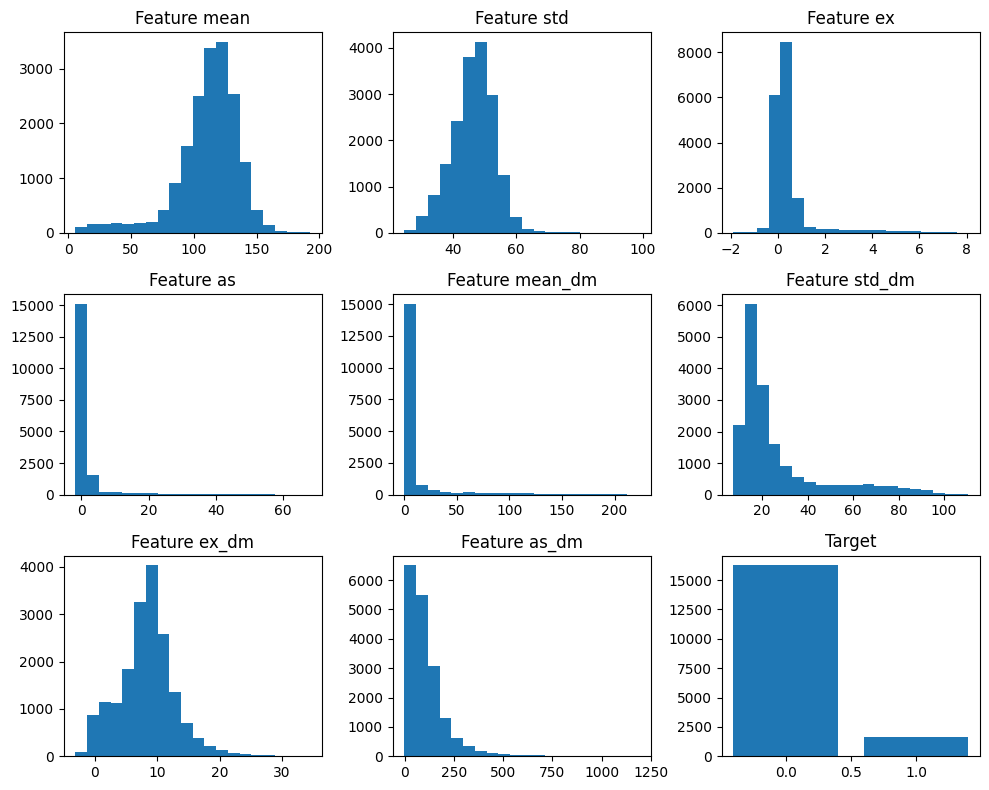

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

for i, ax in enumerate(axes.flat[:-1]):
    ax.hist(df.iloc[:, i], bins=20)
    ax.set_title(f'Feature {df.columns[i]}')

axes[2, 2].bar(df.iloc[:, -1].value_counts().index, df.iloc[:, -1].value_counts().values)
axes[2, 2].set_title('Target')

plt.tight_layout()
plt.show()

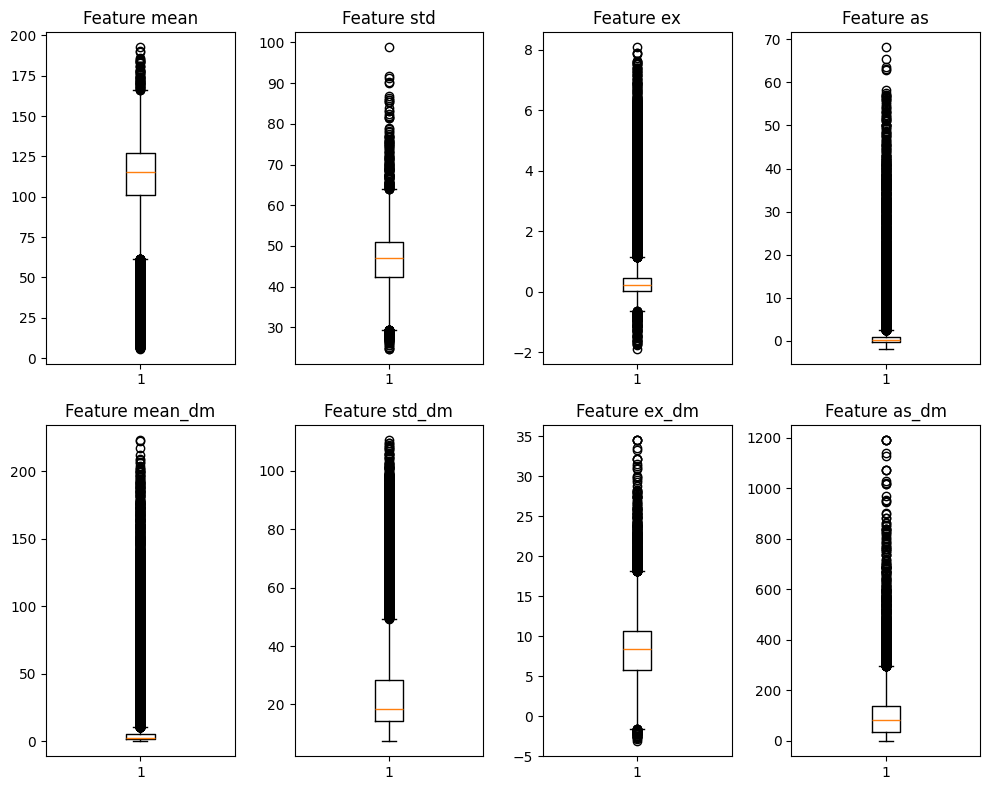

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.boxplot(df.iloc[:, i])
    ax.set_title(f'Feature {df.columns[i]}')

plt.tight_layout()
plt.show()

| Номер | Распределение | Выбросы |
|---|---|---|
| 1 | Нормальное | Есть |
| 2 | Лог-нормальное | Есть |
| 3 | Лог-нормальное | Нет |
| 4 | Экспоненциальное | Нет |
| 5 | Экспоненциальное | Нет |
| 6 | Лог-нормальное | Нет |
| 7 | Лог-нормальное | Есть |
| 8 | Экспоненциальное | Нет |

#### Корреляционная матрица признаков

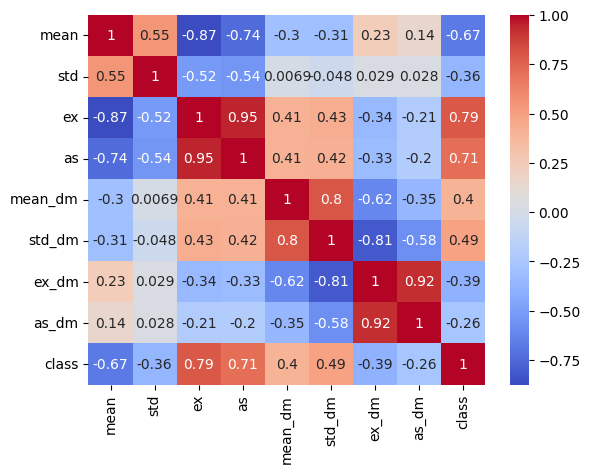

In [31]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


- Присудствуют сильные корреляции между признаками (их модно удалить)
- Есть корреляции между признаками и целевой переменной

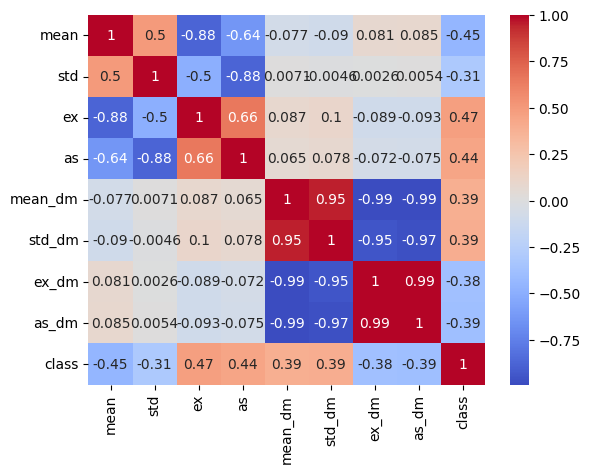

In [32]:
# Бонус
corr_matrix = df.corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Диаграммы рассеяния

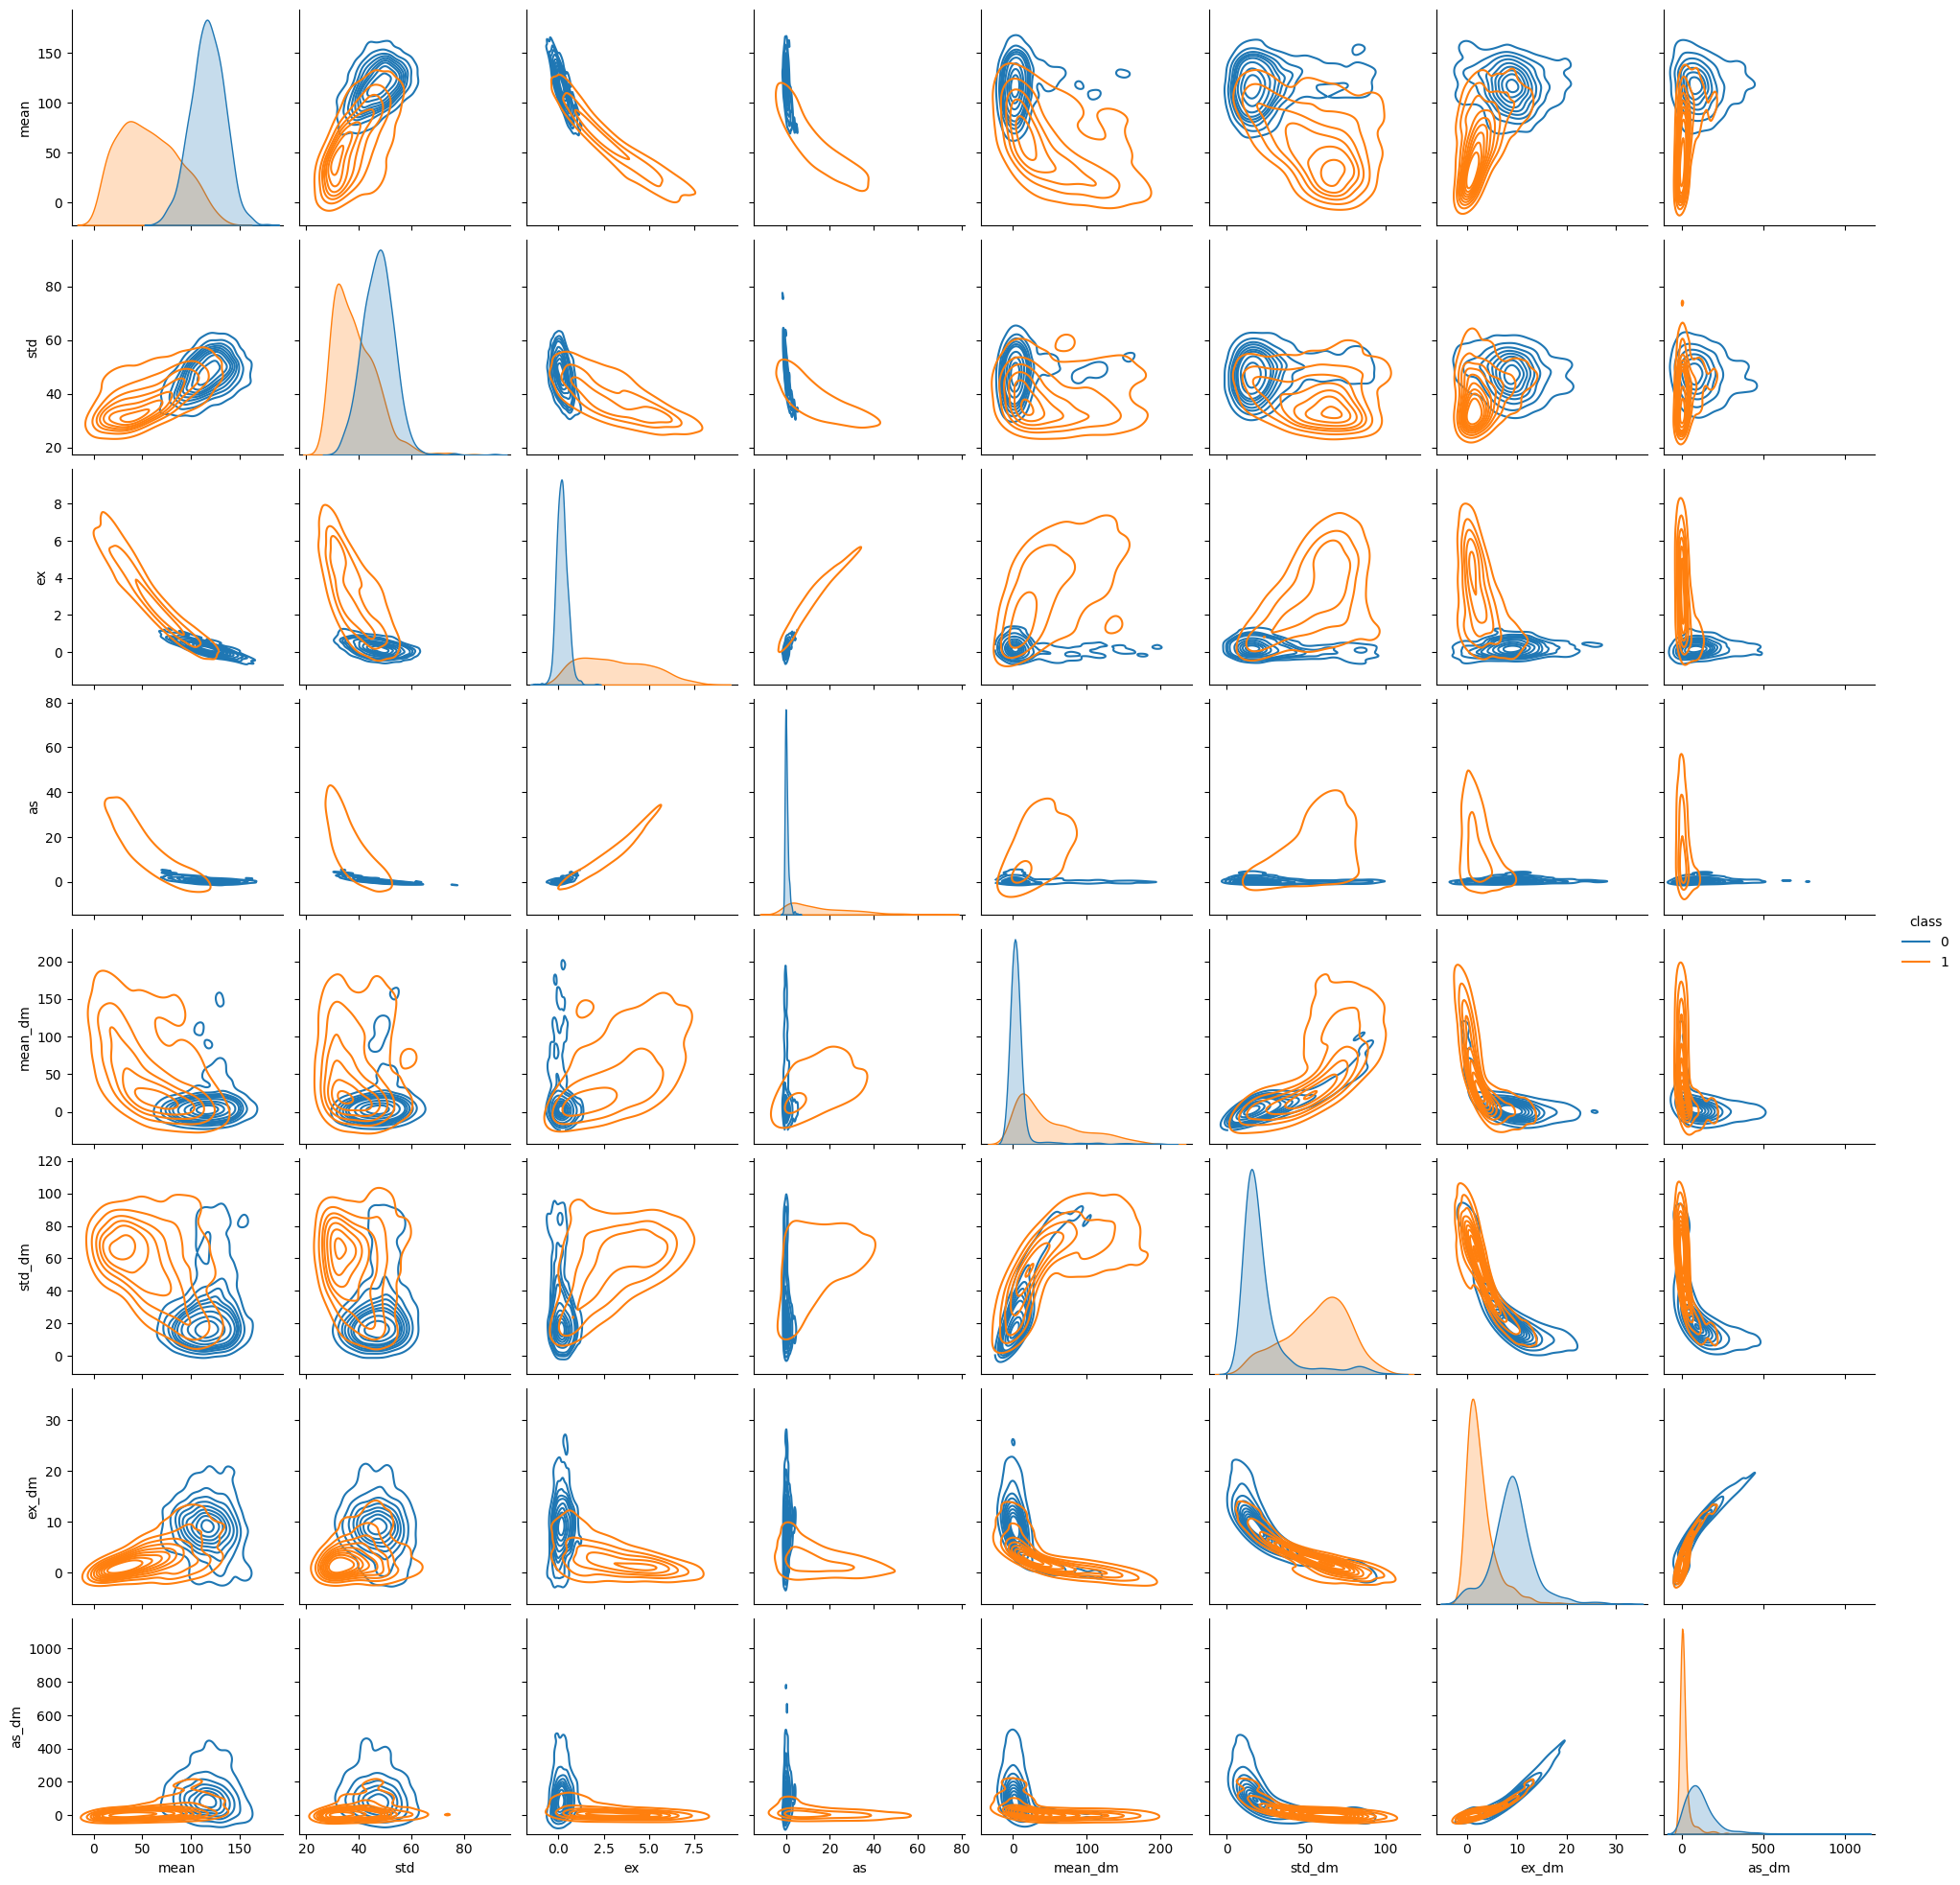

In [33]:
sample = pd.concat([df[df['class'] == 0].sample(1000), df[df['class'] == 1].sample(1000)])
sns.pairplot(sample, hue='class', kind='kde')
plt.show()

Есть как почти не пересекающиюся признаки, так и сильно друг с другом смешанные.

### Выводы

Надо:
- оставить все выбросы, так как они не сильно влияют на метрики задач классификации
- сбалансировать распределение классов при помощи KNNSampling
- убрать сильнокоррклирующие по спирману as_dm и std_dm
- посторить log от данных и посмотреть на их матрицу корреляций
- посмотреть как можно скомбинировать полученные данные для получения новых признаков

## Предобработка данных

### Очистка данных

#### Обнаружение и устранение дубликатов

In [34]:
df.duplicated().sum()

np.int64(0)

*Дупликатов нет*

#### Обнаружение и устранение выбросов

Я не планирую устранять выюросы. Полагаю что именно в них состоит критически важная информация

#### Пропущенные значения

Их нет!

#### Визуальный анализ очищенных данных

Я не изменял датасет. Диаграмы можно увидеть выше в разделе "Визуальный анализ исходных данных"

#### Выводы

После долгой кропотливой работы я... Ничего не сделал.

### Преобразование данных

#### Преобразование входов

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer


In [40]:
preprocess = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
])

df.iloc[:, :8] = preprocess.fit_transform(df.iloc[:, :8])

#### Преобразование выходов

Они уже в идеальном бинарном варианте. Так как мы тренируем нейронную сеть дисбаланс классов не должен сильно влиять на итого. Важно померять не accuracy а f1 в конце.

#### Визуальный анализ преобразованных данных

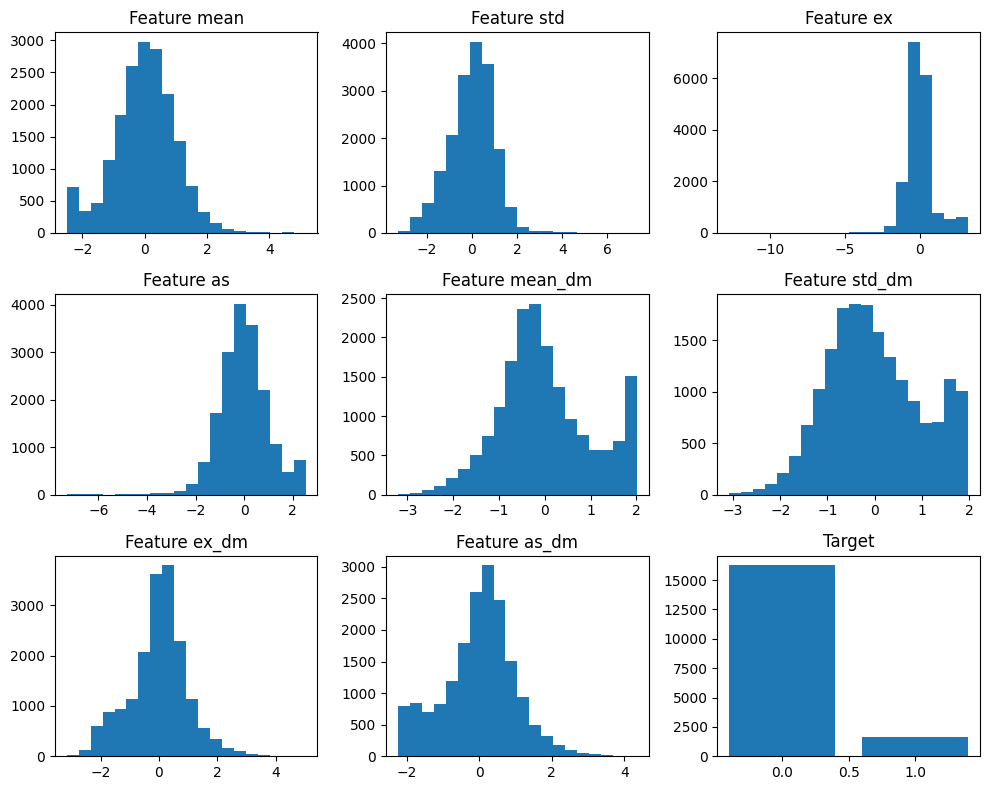

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

for i, ax in enumerate(axes.flat[:-1]):
    ax.hist(df.iloc[:, i], bins=20)
    ax.set_title(f'Feature {df.columns[i]}')

axes[2, 2].bar(df.iloc[:, -1].value_counts().index, df.iloc[:, -1].value_counts().values)
axes[2, 2].set_title('Target')

plt.tight_layout()
plt.show()

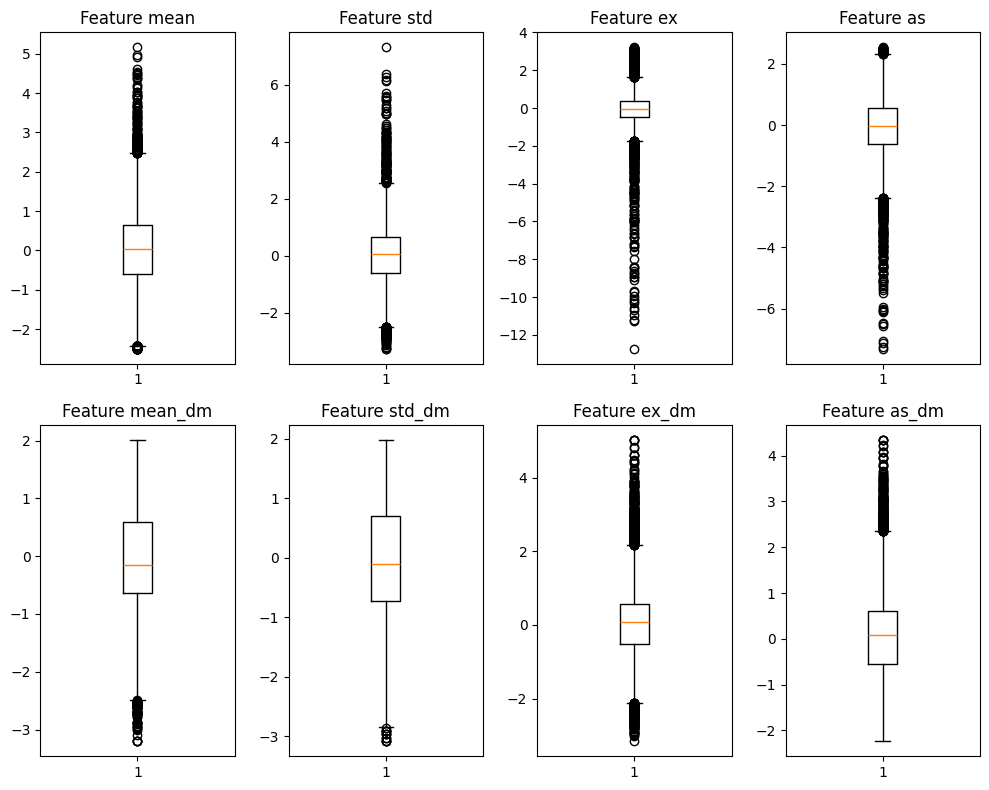

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.boxplot(df.iloc[:, i])
    ax.set_title(f'Feature {df.columns[i]}')

plt.tight_layout()
plt.show()

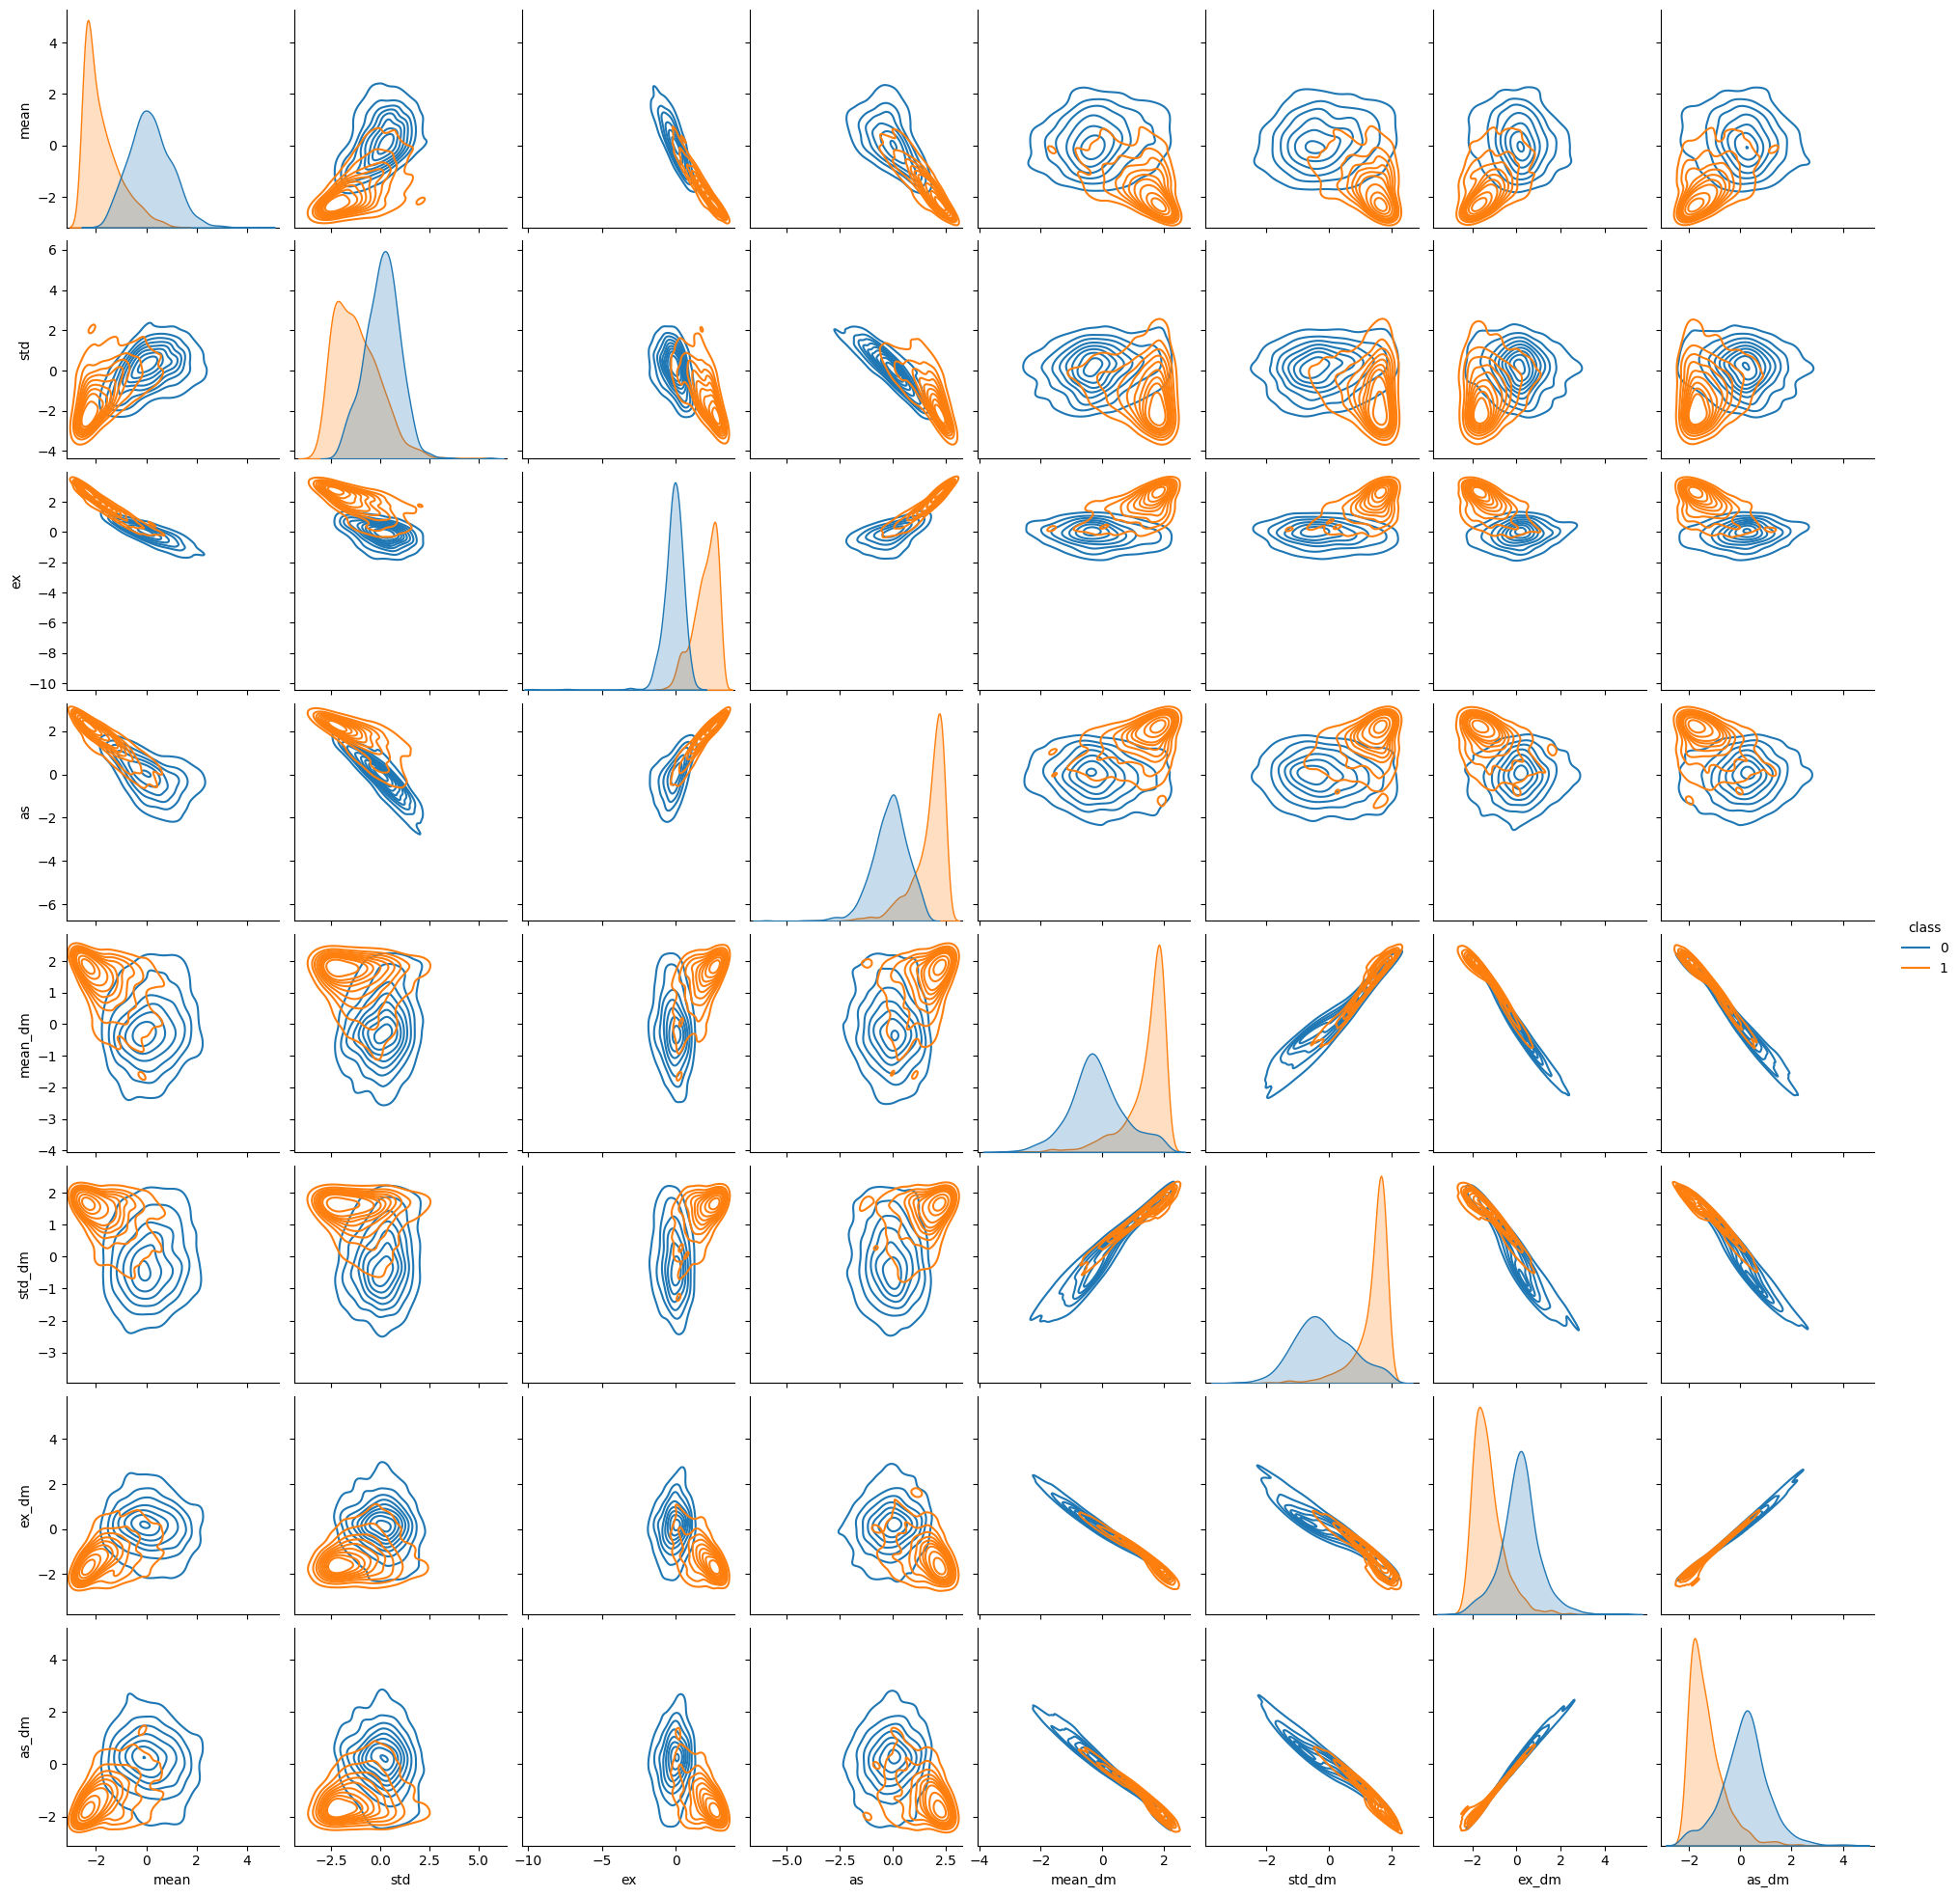

In [43]:
sample = pd.concat([df[df['class'] == 0].sample(1000), df[df['class'] == 1].sample(1000)])
sns.pairplot(sample, hue='class', kind='kde')
plt.show()

<Axes: >

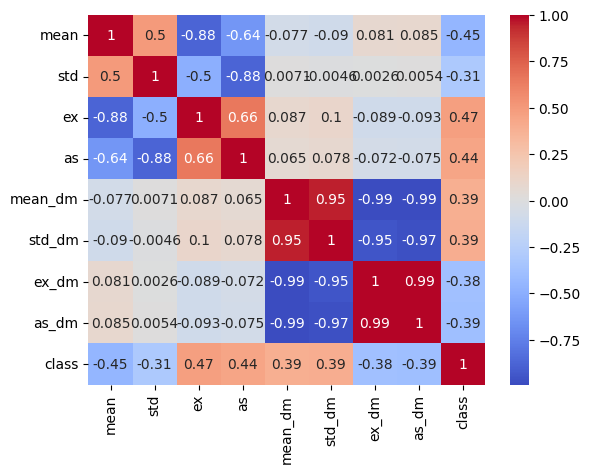

In [46]:
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='coolwarm')

### Выводы

После преобразования, осталось:
- убрать сильнокоррелирующие признаки
- сгенерировать новые признаки

Добавилось:
- использовать f1 для оценки модели а не accuracy

## Формирование признаков

In [127]:
df = pd.read_csv('data/htru2/HTRU_2.csv', header=None)
df.columns = ['mean', 'std', 'ex', 'as', 'mean_dm', 'std_dm', 'ex_dm', 'as_dm', 'class']

In [128]:
preprocess = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
])

### Конструирование новых признаков

In [129]:
from sklearn.base import BaseEstimator, TransformerMixin


class HTRUFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, eps=1e-6, q=0.95):
        self.eps = eps
        self.q = q

    @staticmethod
    def _signed_log(x):
        return np.sign(x) * np.log1p(np.abs(x))

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        cols = X.columns.tolist()
        if len(cols) < 8:
            raise ValueError("Expected at least 8 feature columns for HTRU2.")

        self.base_cols_ = cols[:8]
        p_mean, p_std, p_kurt, p_skew, d_mean, d_std, d_kurt, d_skew = self.base_cols_

        self.flag_thresholds_ = {
            "p_kurt_abs": X[p_kurt].abs().quantile(self.q),
            "p_skew_abs": X[p_skew].abs().quantile(self.q),
            "d_kurt_abs": X[d_kurt].abs().quantile(self.q),
            "d_skew_abs": X[d_skew].abs().quantile(self.q),
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        p_mean, p_std, p_kurt, p_skew, d_mean, d_std, d_kurt, d_skew = self.base_cols_

        fe = X.copy()

        # Stabilized heavy-tail transforms
        fe["p_kurt_log"] = self._signed_log(fe[p_kurt])
        fe["p_skew_log"] = self._signed_log(fe[p_skew])
        fe["d_kurt_log"] = self._signed_log(fe[d_kurt])
        fe["d_skew_log"] = self._signed_log(fe[d_skew])

        # Cross-domain differences/ratios (profile vs DM-SNR)
        fe["mean_diff"] = fe[p_mean] - fe[d_mean]
        fe["std_ratio"] = fe[p_std] / (fe[d_std] + self.eps)
        fe["kurt_diff"] = fe[p_kurt] - fe[d_kurt]
        fe["skew_diff"] = fe[p_skew] - fe[d_skew]

        # A few interactions
        fe["p_std_x_p_kurt"] = fe[p_std] * fe[p_kurt]
        fe["d_std_x_d_kurt"] = fe[d_std] * fe[d_kurt]
        fe["p_skew_x_d_skew"] = fe[p_skew] * fe[d_skew]

        # Outlier flags from TRAIN quantiles only (stored in fit)
        fe["flag_p_kurt_abs_high"] = (fe[p_kurt].abs() > self.flag_thresholds_["p_kurt_abs"]).astype(int)
        fe["flag_p_skew_abs_high"] = (fe[p_skew].abs() > self.flag_thresholds_["p_skew_abs"]).astype(int)
        fe["flag_d_kurt_abs_high"] = (fe[d_kurt].abs() > self.flag_thresholds_["d_kurt_abs"]).astype(int)
        fe["flag_d_skew_abs_high"] = (fe[d_skew].abs() > self.flag_thresholds_["d_skew_abs"]).astype(int)

        return fe

df = HTRUFeatureEngineer().fit_transform(df)

### Сокращение числа признаков

In [ ]:
df.drop(columns=['std_dm', 'ex_dm', 'as_dm', 'p_skew_log', 
                 'p_kurt_log', 'd_kurt_log', 'd_skew_log',
                 'kurt_diff', 'skew_diff', 'p_std_x_p_kurt',
                 'flag_p_kurt_abs_high', 'flag_d_kurt_abs_high',
], inplace=True)

<Axes: >

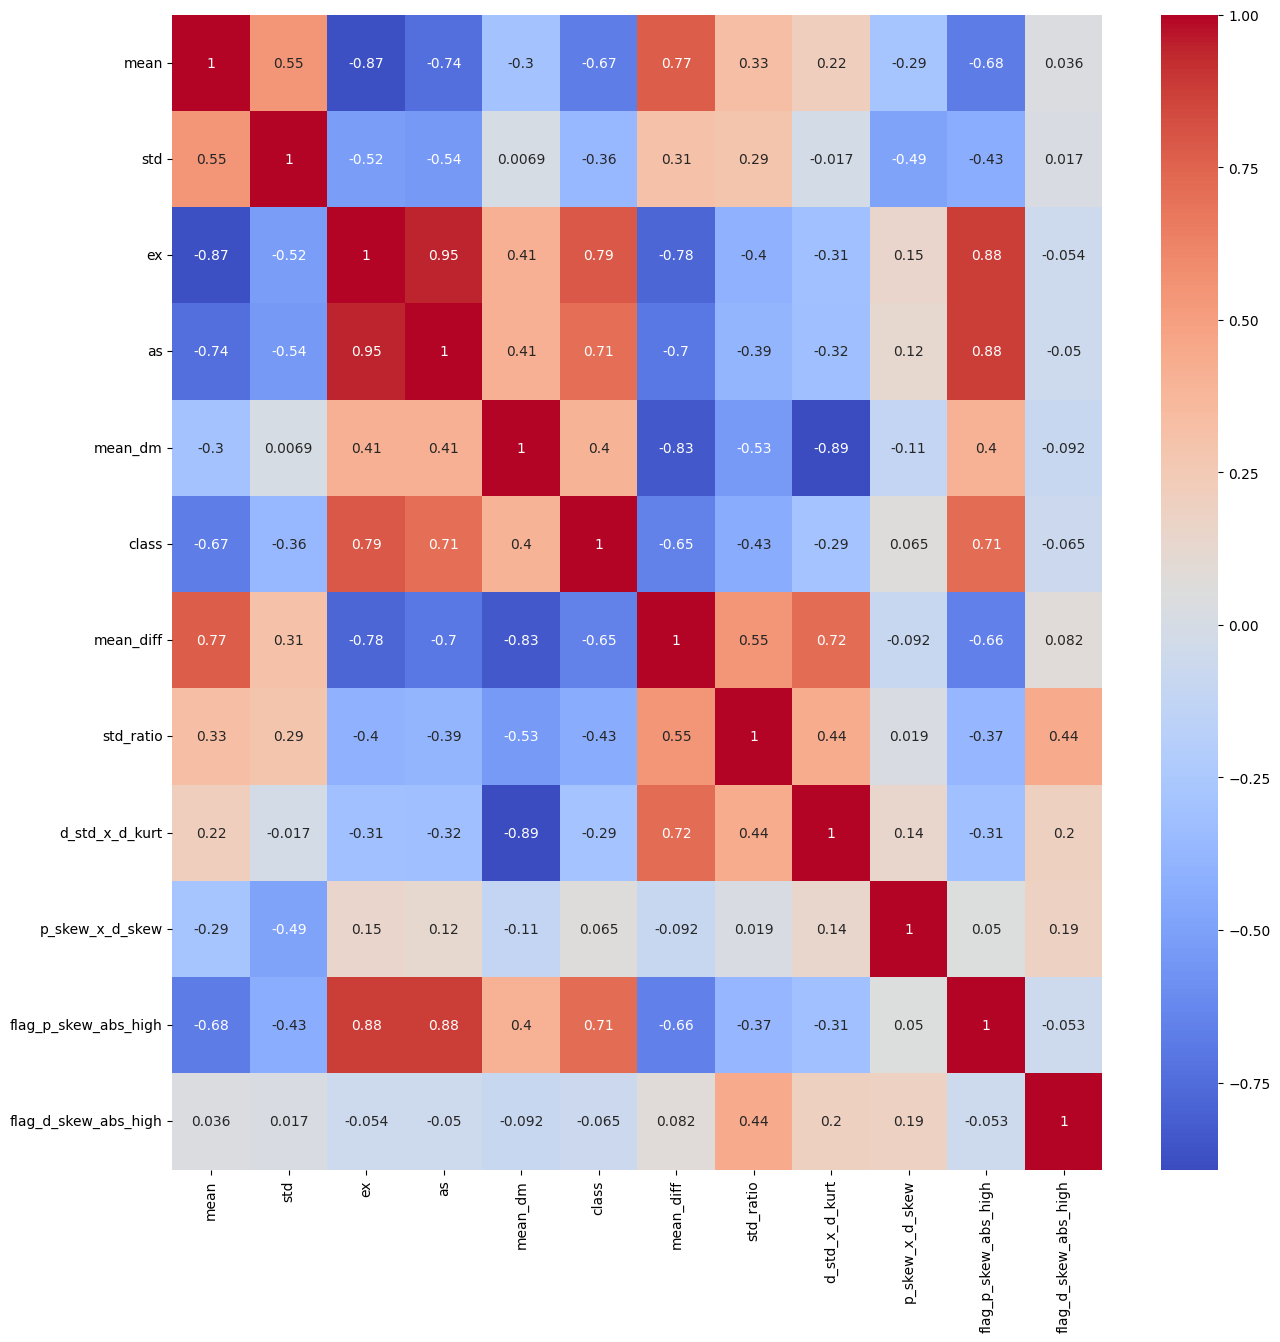

In [131]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')